In [1]:
import pathlib
import json
import re
import os

import cycler
from IPython.display import display, Markdown
import matplotlib.pyplot
import numpy
import polars
from tqdm.notebook import tqdm

EVALUATION_DIR = pathlib.Path.cwd() / "06_1evaluation"
os.environ["EVALUATION_DIR"] = str(EVALUATION_DIR)

##### Terminal 1 (on remote proxy host)

```console
$ cd 06_1evaluation  # TBD reflect rename
$ ./start_remote_setup.sh up
...
 ✔ Network 06_1evaluation_remote           Created                                                                                    0.1s
 ✔ Container 06_1evaluation-remote-proxy-1 Created                                                                                    0.1s
Attaching to remote-proxy-1
```

##### Terminal 2 (on local proxy host)

```console
$ cd 06_1evaluation  # TBD reflect rename
$ TRANCO_LOWER_LIMIT=0 TRANCO_UPPER_LIMIT=100 LIGHTHOUSE_LOG_EXTRA="<note on remote proxy, e.g. location>" PUID=$(id -u) PGID=$(id -g) PROXY_REMOTE_HOST="<remote proxy hostname or IPv4 address>" ./start_local_setup.sh up
...
lighthouse-1   | Updating certificates in /etc/ssl/certs...
lighthouse-1   | rehash: warning: skipping ca-certificates.crt, it does not contain exactly one certificate or CRL
lighthouse-1   | 1 added, 0 removed; done.
lighthouse-1   | Running hooks in /etc/ca-certificates/update.d...
lighthouse-1   | done.
lighthouse-1   | Please configure the local proxy and Chrome with the mitmproxy
lighthouse-1   | certificates. For the local proxy use docker `exec` with bash
lighthouse-1   | and configure them for a Debian system. For Chrome go to
lighthouse-1   | https://localhost:3001. See
lighthouse-1   | https://docs.mitmproxy.org/archive/v12/concepts/certificates/
lighthouse-1   | for how to do that. Set the DNS provider of Chrome to
lighthouse-1   | https://dns.google/dns-query and use docker `exec` to
lighthouse-1   | `touch ~/tls_configured`. The experiments will start
lighthouse-1   | shortly after. You can then close the https://localhost:3001 tab.
lighthouse-1   |
lighthouse-1   | DO NOT CLOSE CHROME WITHIN THAT TAB!
...
```

##### Terminal 3 (on local proxy host)

```console
$ cd 06_1evaluation  # TBD reflect rename
$ rsync -avz "<remote proxy SSH user>@<remote proxy SSH host>:<path to repo on remote proxy>/06_1evaluation/mitmproxy-remote/mitmproxy-ca-cert.pem mitmproxy-remote/"; ./start_local_setup.sh exec -ti local-proxy /app/update_certificate.sh /mitmproxy-remote/mitmproxy-ca-cert.pem
```

##### In Browser via https://localhost:3001 (on local proxy host)

Chrome Version (2026-04-22): 147.0.7727.101

1. **Create an exception for self-signed certificate of localhost:3001**
2.  

##### On certificate errors

**Terminal 1 (on remote proxy host):**
``` console
$ ./start_remote_setup.sh down
```

**Terminal 2 (on local proxy host):**

```console
$ TRANCO_LOWER_LIMIT=0 TRANCO_UPPER_LIMIT=100 LIGHTHOUSE_LOG_EXTRA="<note on remote proxy, e.g. location>" PUID=$(id -u) PGID=$(id -g) PROXY_REMOTE_HOST="<remote proxy hostname or IPv4 address>" ./start_local_setup.sh down
```

Restart from top

##### Start experiment in Terminal 3 (on local proxy host)

```console
$ ./start_local_setup.sh exec -ti lighthouse touch /config/tls_configured
```

In [2]:
fcps = []
jsons = list((EVALUATION_DIR / "output-dataset").glob("lighthouse-run-*.report.json"))

for json_report in tqdm(jsons):
    with open(json_report) as json_file:
        obj = json.load(json_file)
        try:
            fcp = obj["audits"]["first-contentful-paint"]["numericValue"]
            error = None
        except KeyError:
            fcp = None
            error = obj["runtimeError"]["code"]

            if error == "ERRORED_DOCUMENT_REQUEST":
                match = re.search(r"Status code: (\d+)", obj["runtimeError"]["message"])
                error = f"{error} (Status: {match[1]})"
        if not error:
            lcp = obj["audits"]["largest-contentful-paint"].get("numericValue")
            speed_index = obj["audits"]["speed-index"].get("numericValue")
            total_blocking_time = obj["audits"]["total-blocking-time"].get("numericValue")
            cumulative_layout_shift = obj["audits"]["cumulative-layout-shift"].get("numericValue")
        else:
            lcp = None
            speed_index = None
            total_blocking_time = None
            cumulative_layout_shift = None
        match = re.match(r"lighthouse-run-(?P<domain>.*)-(?P<run>\d{3})-(?P<compress>true|false)-(?P<packed>true|false)-(?P<lhts>\d+)(?P<extra>.*)?\.report\.json", json_report.name)
        
        res = match.groupdict()
        res["run"] = int(res["run"])
        res["compress"] = res["compress"] == "true"
        res["packed"] = res["packed"] == "true"
        res["lhts"] = int(res["lhts"])
        res["extra"] = res["extra"].strip("-_")
        res["fcp"] = fcp
        res["lcp"] = lcp
        res["speed_index"] = speed_index
        res["total_blocking_time"] = total_blocking_time
        res["cumulative_layout_shift"] = cumulative_layout_shift
        res["error"] = error
        res["filename"] = json_report.name
        fcps.append(res)

df = polars.DataFrame(fcps).rename(
    {
        "lhts": "lighthouse_timestamp",
        "fcp": "first_contentful_paint",
        "lcp": "largest_contentful_paint",
    }
).with_columns(
    polars.from_epoch(
        polars.col("lighthouse_timestamp")
    ).dt.convert_time_zone(time_zone="Europe/Berlin")
)
df.write_parquet(EVALUATION_DIR / "output-dataset" / "lighthouse.parquet")
df

  0%|          | 0/2000 [00:00<?, ?it/s]

domain,run,compress,packed,lighthouse_timestamp,extra,first_contentful_paint,largest_contentful_paint,speed_index,total_blocking_time,cumulative_layout_shift,error,filename
str,i64,bool,bool,"datetime[μs, Europe/Berlin]",str,f64,f64,f64,f64,f64,str,str
"""1mjav.com""",1,false,false,2026-04-22 16:22:51 CEST,"""us-west""",null,null,null,null,null,"""NO_FCP""","""lighthouse-run-1mjav.com-001-f…"
"""1mjav.com""",1,true,false,2026-04-22 16:05:38 CEST,"""us-west""",null,null,null,null,null,"""NO_FCP""","""lighthouse-run-1mjav.com-001-t…"
"""1mjav.com""",2,false,false,2026-04-23 13:06:38 CEST,"""us-west""",null,null,null,null,null,"""NO_FCP""","""lighthouse-run-1mjav.com-002-f…"
"""1mjav.com""",2,true,false,2026-04-23 11:11:53 CEST,"""us-west""",null,null,null,null,null,"""NO_FCP""","""lighthouse-run-1mjav.com-002-t…"
"""1mjav.com""",3,false,false,2026-04-23 16:57:32 CEST,"""us-west""",null,null,null,null,null,"""NO_FCP""","""lighthouse-run-1mjav.com-003-f…"
…,…,…,…,…,…,…,…,…,…,…,…,…
"""myrightonline.li""",5,false,false,2026-04-24 22:21:44 CEST,"""us-west""",8645.7175,8645.7175,17466.925788,104.0,0.18425,null,"""lighthouse-run-myrightonline.l…"
"""nopsema.gov.au""",5,false,false,2026-04-24 22:22:13 CEST,"""us-west""",3971.332,18746.332,10161.157439,365.0,0.0,null,"""lighthouse-run-nopsema.gov.au-…"
"""scredit.com.my""",5,false,false,2026-04-24 22:22:36 CEST,"""us-west""",null,null,null,null,null,"""CHROME_INTERSTITIAL_ERROR""","""lighthouse-run-scredit.com.my-…"


Metric,min.,max.,mean,std,median
str,f64,f64,f64,f64,f64
"""first_contentful_paint""",-1256.4579,3181.139509,39.719836,540.57966,17.5732
"""largest_contentful_paint""",-6501.18376,27835.205717,253.991571,2789.697742,51.40822
"""speed_index""",-5540.996012,6616.488234,93.197485,1471.418099,-3.76457


## [Lighthouse Metrics (CDF)](06_1evaluation/plots/lighthouse-cdf.pdf)

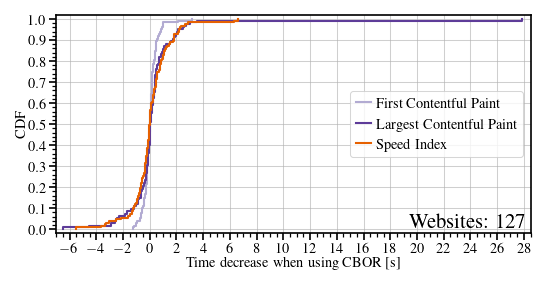

In [3]:
matplotlib.style.use(pathlib.Path.cwd() / "mlenders_column_ieeetran.mplstyle")
matplotlib.rcParams["figure.figsize"] = (
    matplotlib.rcParams["figure.figsize"][0] * 1.0,
    matplotlib.rcParams["figure.figsize"][1] * 6 / 8,
)

df = polars.read_parquet(EVALUATION_DIR / "output-dataset" / "lighthouse.parquet")

fig = matplotlib.pyplot.figure(
    figsize=matplotlib.rcParams["figure.figsize"],
    dpi=150,
)
ax = matplotlib.pyplot.gca()
stats = None

METRIC_COLORS = {
    "first_contentful_paint": "#b2abd2",
    "largest_contentful_paint": "#5e3c99",
    "speed_index": "#e66101",
    "total_blocking_time": "#fdb863",
}

for metric in [
    "first_contentful_paint",
    "largest_contentful_paint",
    "speed_index",
    #"total_blocking_time",
]:
    times = df.filter(~polars.col("packed")).select(
        ["compress", "domain", "run", metric]
    ).pivot(
        "compress",
        index=["domain", "run"],
        values=[metric]
    ).filter(
        polars.col("true").is_not_null()
        & polars.col("false").is_not_null()
    ).rename(
        {
            "true": "Compressed",
            "false": "Not compressed",
        }
    ).with_columns(
        Difference=polars.col("Not compressed") - polars.col("Compressed")
    ).select(["domain", "Compressed", "Not compressed", "Difference"]).group_by("domain").mean()
    # display(times)
    domains = times.select(polars.col("domain").unique()).shape[0]
    # audits = times.shape[0]
    #matplotlib.pyplot.clf()

    comp = "Difference"
    ax.ecdf(times[comp], label=metric.replace("_", " ").title(), color=METRIC_COLORS[metric])
    stat = polars.DataFrame(
        [
            {
                "Metric": metric,
                "min.": times[comp].min(),
                "max.": times[comp].max(),
                "mean": times[comp].mean(),
                "std": times[comp].std(),
                "median": times[comp].median(),
            }
        ]
    )
    if stats is None:
        stats = stat
    else:
        stats = polars.concat([stats, stat])
display(stats)
ax.set_xlabel(f"Time decrease when using CBOR [s]")
ax.set_xlim(-7000, 28500)
ax.set_xticks(numpy.arange(-6000, 28600, 2000))
ax.set_xticks(numpy.arange(-7000, 28600, 500), minor=True)
ax.grid()
ax.xaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, pos: f"${x / 1000.0:.0f}$"))
ax.set_ylabel("CDF")
ax.set_ylim(-0.02, 1.02)
ax.set_yticks(numpy.arange(0, 1.1, 0.1))
ax.set_yticks(numpy.arange(0, 1.02, 0.02), minor=True)
ax.text(
    0.99,
    0.01,
    f"Websites: {domains}", # (successful audits / site: {audits / domains:.2f} / 3.00)", 
    ha="right",
    va="bottom",
    transform=ax.transAxes,
)
ax.legend(loc="center right")
filepath = EVALUATION_DIR / "plots" / "lighthouse-cdf.pdf"
display(
    Markdown(
        f"## [Lighthouse Metrics (CDF)]({str(filepath.relative_to(pathlib.Path.cwd()))})"
    )
)
matplotlib.pyplot.savefig(filepath, bbox_inches="tight", pad_inches=0.01)
matplotlib.pyplot.show()

metric,min.,max.,mean,std.,median
str,f64,f64,f64,f64,f64
"""first_contentful_paint""",-1256.4579,3181.139509,40.674517,540.268186,17.5732
"""largest_contentful_paint""",-6501.18376,27835.205717,275.768044,2775.464558,51.40822
"""speed_index""",-5540.996012,6616.488234,93.197485,1471.418099,-3.76457


## [Lighthouse Metrics (Violin Plot)](06_1evaluation/plots/lighthouse-violin.pdf)

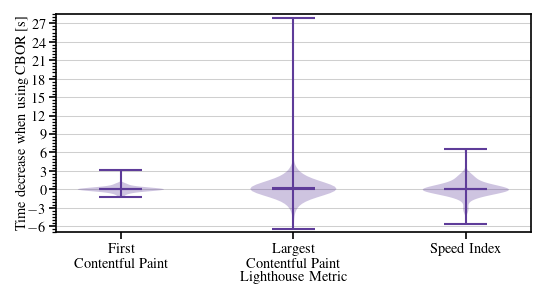

domain,metric,value
str,str,f64


In [4]:
matplotlib.style.use(pathlib.Path.cwd() / "mlenders_column_ieeetran.mplstyle")
matplotlib.rcParams["figure.figsize"] = (
    matplotlib.rcParams["figure.figsize"][0] * 1.0,
    matplotlib.rcParams["figure.figsize"][1] * 6 / 8,
)

df = polars.read_parquet(EVALUATION_DIR / "output-dataset" / "lighthouse.parquet")

fig = matplotlib.pyplot.figure(
    figsize=matplotlib.rcParams["figure.figsize"],
    dpi=150,
)
ax = matplotlib.pyplot.gca()
stats = None
metrics = ["first_contentful_paint", "largest_contentful_paint", "speed_index"] #, "total_blocking_time"]

METRIC_XAXIS_LABEL = {
    "first_contentful_paint": "First\nContentful Paint",
    "largest_contentful_paint": "Largest\nContentful Paint",
    "speed_index": "Speed Index",
    "total_blocking_time": "Total\nBlocking Time"
}

times = df.filter(~polars.col("packed")).select(
    ["compress", "domain", "run"] + metrics
# ).filter(
#     polars.col("run") != 2
).pivot(
    "compress",
    index=["domain", "run"],
    values=metrics,
).with_columns(
    **{
        # ~compressed - compressed
        k: polars.col(f"{k}_false") - polars.col(f"{k}_true")
        for k in metrics
    }
).filter(
    polars.col("first_contentful_paint").is_not_null()
    & polars.col("largest_contentful_paint").is_not_null()
    & polars.col("speed_index").is_not_null()
    # & polars.col("total_blocking_time").is_not_null()
).select(
    ["domain"] + metrics
).group_by("domain").mean()

stats = polars.DataFrame(
    [
        {
            "metric": k,
            "min.": times[k].min(),
            "max.": times[k].max(),
            "mean": times[k].mean(),
            "std.": times[k].std(),
            "median": times[k].median(),
        }
        for k in metrics
    ],
)

display(stats)

ax.set_prop_cycle(cycler.cycler(color=["#5e3c99"]))
ax.violinplot(
    times[metrics],
    showmeans=True,
    showmedians=True,
)
ax.set_axisbelow(True)
ax.grid(axis="y")
ax.set_xlabel(f"Lighthouse Metric")
ax.set_xticks(range(1, len(metrics) + 1), [METRIC_XAXIS_LABEL[m] for m in metrics])
ax.set_ylabel(f"Time decrease when using CBOR [s]")
ax.set_ylim(-7000, 28500)
ax.set_yticks(numpy.arange(-6000, 28600, 3000))
ax.set_yticks(numpy.arange(-7000, 28600, 500), minor=True)
ax.yaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda y, pos: f"${y / 1000.0:.0f}$"))
filepath = EVALUATION_DIR / "plots" / "lighthouse-violin.pdf"
display(
    Markdown(
        f"## [Lighthouse Metrics (Violin Plot)]({str(filepath.relative_to(pathlib.Path.cwd()))})"
    )
)
matplotlib.pyplot.savefig(filepath, bbox_inches="tight", pad_inches=0.01)
matplotlib.pyplot.show()
display(times.unpivot(index="domain", variable_name="metric", value_name="value").filter(polars.col("value") < -12000))

In [5]:
with polars.Config(fmt_str_lengths=df["error"].str.len_chars().max(), tbl_rows=162):
    display(
        df.filter(
            polars.col("error").is_not_null()
        ).select(
            ["domain", "run", "compress", "error"]
        ).pivot(
            "run",
            index=["domain", "compress"],
            values="error"
        ).rename(
            {
                str(k): f"run_{k:02d}"
                for k in range(1, 6)
            }
        ).lazy().join(
            polars.scan_csv(EVALUATION_DIR / "tranco_3QL4L.csv", has_header=False, new_columns=["rank", "domain"]),
            on="domain",
        ).select(
            ["rank", "domain", "compress"] + [f"run_{k:02d}" for k in range(1, 6)]
        ).sort(["rank", "compress"]).collect()
    )

rank,domain,compress,run_01,run_02,run_03,run_04,run_05
i64,str,bool,str,str,str,str,str
2,"""gtld-servers.net""",false,"""CHROME_INTERSTITIAL_ERROR""","""CHROME_INTERSTITIAL_ERROR""","""CHROME_INTERSTITIAL_ERROR""","""CHROME_INTERSTITIAL_ERROR""","""CHROME_INTERSTITIAL_ERROR"""
2,"""gtld-servers.net""",true,"""CHROME_INTERSTITIAL_ERROR""","""CHROME_INTERSTITIAL_ERROR""","""CHROME_INTERSTITIAL_ERROR""","""CHROME_INTERSTITIAL_ERROR""","""CHROME_INTERSTITIAL_ERROR"""
3,"""gstatic.com""",false,"""ERRORED_DOCUMENT_REQUEST (Status: 404)""","""ERRORED_DOCUMENT_REQUEST (Status: 404)""","""ERRORED_DOCUMENT_REQUEST (Status: 404)""","""ERRORED_DOCUMENT_REQUEST (Status: 404)""","""ERRORED_DOCUMENT_REQUEST (Status: 404)"""
3,"""gstatic.com""",true,"""ERRORED_DOCUMENT_REQUEST (Status: 404)""","""ERRORED_DOCUMENT_REQUEST (Status: 404)""","""ERRORED_DOCUMENT_REQUEST (Status: 404)""","""ERRORED_DOCUMENT_REQUEST (Status: 404)""","""ERRORED_DOCUMENT_REQUEST (Status: 404)"""
6,"""googleapis.com""",false,"""ERRORED_DOCUMENT_REQUEST (Status: 404)""","""ERRORED_DOCUMENT_REQUEST (Status: 404)""","""ERRORED_DOCUMENT_REQUEST (Status: 404)""","""ERRORED_DOCUMENT_REQUEST (Status: 404)""","""ERRORED_DOCUMENT_REQUEST (Status: 404)"""
6,"""googleapis.com""",true,"""ERRORED_DOCUMENT_REQUEST (Status: 404)""","""ERRORED_DOCUMENT_REQUEST (Status: 404)""","""ERRORED_DOCUMENT_REQUEST (Status: 404)""","""ERRORED_DOCUMENT_REQUEST (Status: 404)""","""ERRORED_DOCUMENT_REQUEST (Status: 404)"""
9,"""youtube.com""",true,null,"""CHROME_INTERSTITIAL_ERROR""",null,null,null
12,"""pv-cdn.net""",false,"""CHROME_INTERSTITIAL_ERROR""","""CHROME_INTERSTITIAL_ERROR""","""CHROME_INTERSTITIAL_ERROR""","""CHROME_INTERSTITIAL_ERROR""","""CHROME_INTERSTITIAL_ERROR"""
12,"""pv-cdn.net""",true,"""CHROME_INTERSTITIAL_ERROR""","""CHROME_INTERSTITIAL_ERROR""","""CHROME_INTERSTITIAL_ERROR""","""CHROME_INTERSTITIAL_ERROR""","""CHROME_INTERSTITIAL_ERROR"""


In [6]:
df.filter(polars.col("error") == "NO_FCP")

domain,run,compress,packed,lighthouse_timestamp,extra,first_contentful_paint,largest_contentful_paint,speed_index,total_blocking_time,cumulative_layout_shift,error,filename
str,i64,bool,bool,"datetime[μs, Europe/Berlin]",str,f64,f64,f64,f64,f64,str,str
"""1mjav.com""",1,false,false,2026-04-22 16:22:51 CEST,"""us-west""",null,null,null,null,null,"""NO_FCP""","""lighthouse-run-1mjav.com-001-f…"
"""1mjav.com""",1,true,false,2026-04-22 16:05:38 CEST,"""us-west""",null,null,null,null,null,"""NO_FCP""","""lighthouse-run-1mjav.com-001-t…"
"""1mjav.com""",2,false,false,2026-04-23 13:06:38 CEST,"""us-west""",null,null,null,null,null,"""NO_FCP""","""lighthouse-run-1mjav.com-002-f…"
"""1mjav.com""",2,true,false,2026-04-23 11:11:53 CEST,"""us-west""",null,null,null,null,null,"""NO_FCP""","""lighthouse-run-1mjav.com-002-t…"
"""1mjav.com""",3,false,false,2026-04-23 16:57:32 CEST,"""us-west""",null,null,null,null,null,"""NO_FCP""","""lighthouse-run-1mjav.com-003-f…"
…,…,…,…,…,…,…,…,…,…,…,…,…
"""vavada-rud.buzz""",5,false,false,2026-04-24 22:00:49 CEST,"""us-west""",null,null,null,null,null,"""NO_FCP""","""lighthouse-run-vavada-rud.buzz…"
"""1mjav.com""",5,false,false,2026-04-24 22:03:51 CEST,"""us-west""",null,null,null,null,null,"""NO_FCP""","""lighthouse-run-1mjav.com-005-f…"
"""movember.com.au""",5,false,false,2026-04-24 22:05:21 CEST,"""us-west""",null,null,null,null,null,"""NO_FCP""","""lighthouse-run-movember.com.au…"


In [7]:
lf = df.select("domain").group_by("domain").len().rename({"len": "runs"}).with_columns(
    polars.col("runs") / 2   # compressed and uncompressed runs are counted here together so devide by 2
).lazy().join(
    polars.scan_csv(EVALUATION_DIR / "tranco_3QL4L.csv", has_header=False, new_columns=["rank", "domain"]),
    on="domain",
).sort("rank")
res = lf.collect()
with polars.Config(tbl_rows=df.shape[0]):
    display(lf.collect())

domain,runs,rank
str,f64,i64
"""google.com""",5.0,1
"""gtld-servers.net""",5.0,2
"""gstatic.com""",5.0,3
"""facebook.com""",5.0,4
"""cloudflare.com""",5.0,5
"""googleapis.com""",5.0,6
"""microsoft.com""",5.0,7
"""mail.ru""",5.0,8
"""youtube.com""",5.0,9


In [8]:
df#.filter((polars.col("run") == 3) & ~polars.col("compress"))

domain,run,compress,packed,lighthouse_timestamp,extra,first_contentful_paint,largest_contentful_paint,speed_index,total_blocking_time,cumulative_layout_shift,error,filename
str,i64,bool,bool,"datetime[μs, Europe/Berlin]",str,f64,f64,f64,f64,f64,str,str
"""1mjav.com""",1,false,false,2026-04-22 16:22:51 CEST,"""us-west""",null,null,null,null,null,"""NO_FCP""","""lighthouse-run-1mjav.com-001-f…"
"""1mjav.com""",1,true,false,2026-04-22 16:05:38 CEST,"""us-west""",null,null,null,null,null,"""NO_FCP""","""lighthouse-run-1mjav.com-001-t…"
"""1mjav.com""",2,false,false,2026-04-23 13:06:38 CEST,"""us-west""",null,null,null,null,null,"""NO_FCP""","""lighthouse-run-1mjav.com-002-f…"
"""1mjav.com""",2,true,false,2026-04-23 11:11:53 CEST,"""us-west""",null,null,null,null,null,"""NO_FCP""","""lighthouse-run-1mjav.com-002-t…"
"""1mjav.com""",3,false,false,2026-04-23 16:57:32 CEST,"""us-west""",null,null,null,null,null,"""NO_FCP""","""lighthouse-run-1mjav.com-003-f…"
…,…,…,…,…,…,…,…,…,…,…,…,…
"""myrightonline.li""",5,false,false,2026-04-24 22:21:44 CEST,"""us-west""",8645.7175,8645.7175,17466.925788,104.0,0.18425,null,"""lighthouse-run-myrightonline.l…"
"""nopsema.gov.au""",5,false,false,2026-04-24 22:22:13 CEST,"""us-west""",3971.332,18746.332,10161.157439,365.0,0.0,null,"""lighthouse-run-nopsema.gov.au-…"
"""scredit.com.my""",5,false,false,2026-04-24 22:22:36 CEST,"""us-west""",null,null,null,null,null,"""CHROME_INTERSTITIAL_ERROR""","""lighthouse-run-scredit.com.my-…"
